#EDA

##DATA PROFILING, CLEANING AND ANALYSIS

###Basic Information


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("concrete.csv")

print("\n\n\nFirst 5 rows of the dataset\n\n")
df.head()




First 5 rows of the dataset




,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [8]:
print("\n\nNumber of rows and columns:",(df.shape),"\n\n")
print(df.info(),"\n\n")
df.describe()



Number of rows and columns: (1030, 9) 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   cement                         1030 non-null   float64
 1   blast_furnace_slag             1030 non-null   float64
 2   fly_ash                        1030 non-null   float64
 3   water                          1030 non-null   float64
 4   superplasticizer               1030 non-null   float64
 5   coarse_aggregate               1030 non-null   float64
 6   fine_aggregate                 1030 non-null   float64
 7   age                            1030 non-null   int64  
 8   concrete_compressive_strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB
None 




,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


This cell reads the .csv file and gives its basic info by using functions like head(),info(),shape,describe()

###Unique Values

In [ ]:
#checking for unique values

print("Unique Values:\n",df.nunique())
print("\nTotal Unique Values:",df.nunique().sum())

This cell checks for unique value and gives all the column with there unique values using nunique() function

###Null values

In [ ]:
#Checking for null values
print("List of null values:\n",df.isnull().sum())
print("\nTotal null values:",df.isnull().sum().sum())

This cell counts the null values and shows all columns with null values


###Duplicated Values

In [ ]:
print("Number of duplicate rows:",df.duplicated().sum())
df=df.drop_duplicates()

Checking the number of duplicate values and removing it

##Feature Engineering

Index(['blast_furnace_slag', 'fly_ash', 'superplasticizer', 'age',
       'concrete_compressive_strength', 'cement/water', 'net_aggregate'],
      dtype='object')

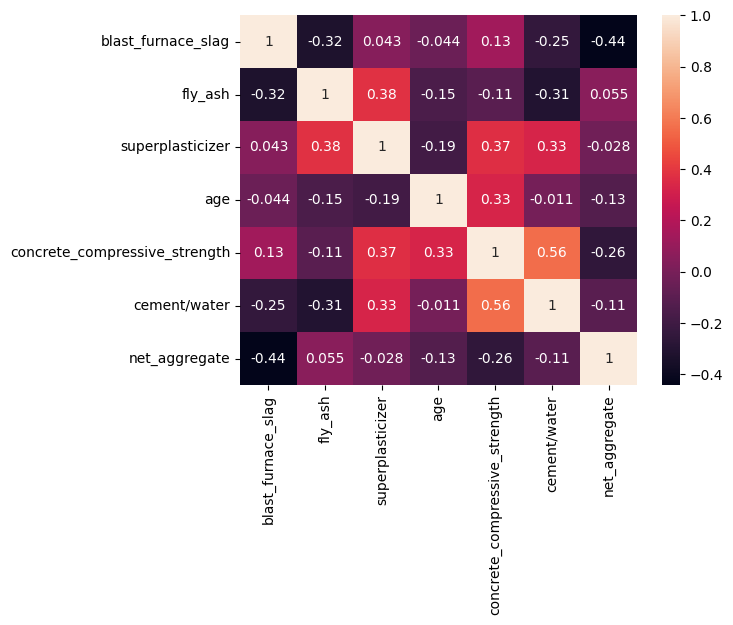

In [19]:
#Creating a new feature
sns.heatmap(df.corr(),annot=True)
# df["cement/water"]=df["cement"]/df["water"]
# df["net_aggregate"]=df["fine_aggregate "]+df["coarse_aggregate"]
# df=df.drop(columns=["fine_aggregate ","coarse_aggregate","cement","water"])
df.columns

Creating a new feature net_aggregate from fine_aggregate and coarse_aggregate because both are negatively correlated

##Visualization

###Histogram

In [ ]:
sns.histplot(df["cement/water"],kde=True)
plt.title("Cement amount  distribution")
plt.show()

In [ ]:
sns.histplot(df["age"],kde=True)
plt.title("Age distribution")
plt.show()

###Bar Graph


In [ ]:
sns.barplot(y="concrete_compressive_strength",x="age",data=df,ci=False)
plt.title("strength vs age bar graph")

###HeatMap


In [ ]:
sns.scatterplot(x="cement/water",y="concrete_compressive_strength",data=df)

###Box Plot

In [ ]:

plt.figure(figsize=(15, 3))
sns.boxplot(data=df)
plt.title("Boxplot Before Outlier Removal")
plt.show()
columns = ['blast_furnace_slag', 'fly_ash', 'superplasticizer', 'age',
           'cement/water', 'net_aggregate']

ndf = df.copy()
for column in columns:
    Q1 = ndf[column].quantile(0.25)
    Q3 = ndf[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    ndf = ndf[(ndf[column] >= lower_limit) & (ndf[column] <= upper_limit)]


In [ ]:
# Show boxplot after outlier removal
plt.figure(figsize=(15, 3))
sns.boxplot(data=ndf)
plt.title("Boxplot After Outlier Removal")
plt.show()

#Regression

Mean Squared Error: 118.6323205473806
Mean Absolute Error: 8.693870758120386
R² Score: 0.5961914335054548


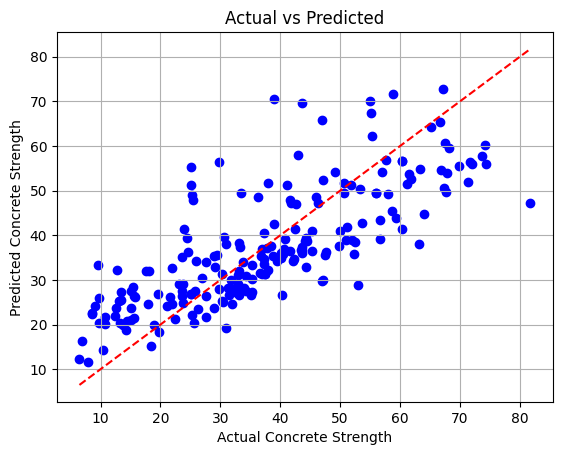

In [20]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X=df.drop(columns="concrete_compressive_strength")
Y=df["concrete_compressive_strength"]

model=LinearRegression()

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=59)
model.fit(X_train,Y_train)

Y_pred=model.predict(X_test)

mse = mean_squared_error(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R² Score:", r2)


plt.scatter(Y_test, Y_pred, color='blue')
plt.xlabel("Actual Concrete Strength")
plt.ylabel("Predicted Concrete Strength")
plt.title("Actual vs Predicted")
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')  # 45-degree line
plt.grid(True)
plt.show()



Best Alpha: 1
Mean Squared Error: 118.86493836088842
Mean Absolute Error: 8.703129850777374
R² Score: 0.5953996335526235


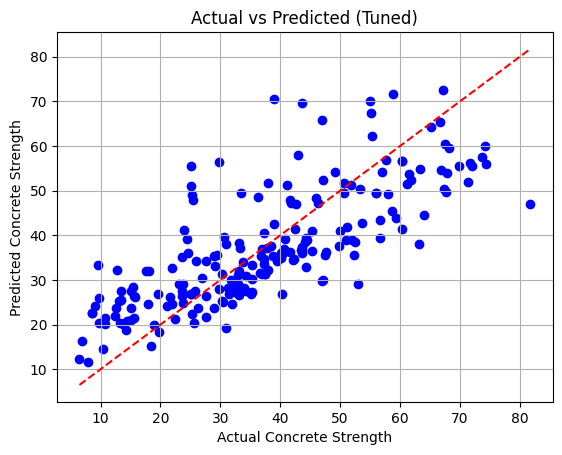

In [21]:
param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}

# Grid search
grid = GridSearchCV(Ridge(), param_grid, cv=5, scoring='r2')
grid.fit(X_train, Y_train)

# Best model after tuning
best_model = grid.best_estimator_

# Prediction
Y_pred = best_model.predict(X_test)

# Evaluation
mse = mean_squared_error(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print("Best Alpha:", grid.best_params_['alpha'])
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R² Score:", r2)

# Plot: Actual vs Predicted
plt.scatter(Y_test, Y_pred, color='blue')
plt.xlabel("Actual Concrete Strength")
plt.ylabel("Predicted Concrete Strength")
plt.title("Actual vs Predicted (Tuned)")
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')  # 45-degree line
plt.grid(True)
plt.show()


#FINDINGS

1. The model is 56% accurate
2. The MSE is 116 and MAE is 8.78
3. cement/water ratio is highly correlated to concrete_strength
4. Both baseline and fin_tuned model gave 59% accuracy

In [23]:
import joblib


# Save model to file
joblib.dump(model, "regression_model.pkl")
joblib.dump(best_model,"fine_tuned.pkl")

['fine_tuned.pkl']